In [1]:

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import xobjects as xo
import xtrack as xt
import xpart as xp
import xcoll as xc

# Make a context and get a buffer
context = xo.ContextCpu()         # For CPU
# context = xo.ContextCupy()      # For CUDA GPUs
# context = xo.ContextPyopencl()  # For OpenCL GPUs

In [2]:
coll = xc.EverestCrystal(length=0.002, material=xc.materials.SiliconCrystal, bending_angle=149e-6,
                         width=0.002, height=0.05, side='+', miscut=0., lattice='strip', jaw=0.001,
                         _context=context)

Creating a beam with gaussian momentum in x

In [3]:
num_part = int(10e6)
x_init   = np.random.normal(loc=1.5e-3, scale=75.e-6, size=num_part)
px_init  = np.random.normal(loc=0, scale=75.e-6, size=num_part)
y_init   = np.random.normal(loc=0., scale=1e-3, size=num_part)
py_init  = np.random.normal(loc=0., scale=5.e-6, size=num_part)
part = xp.Particles(x=x_init, px=px_init, y=y_init, py=py_init, delta=0, p0c=4e11, _context=context)
part_init = part.copy()

In [4]:
coll.track(part)

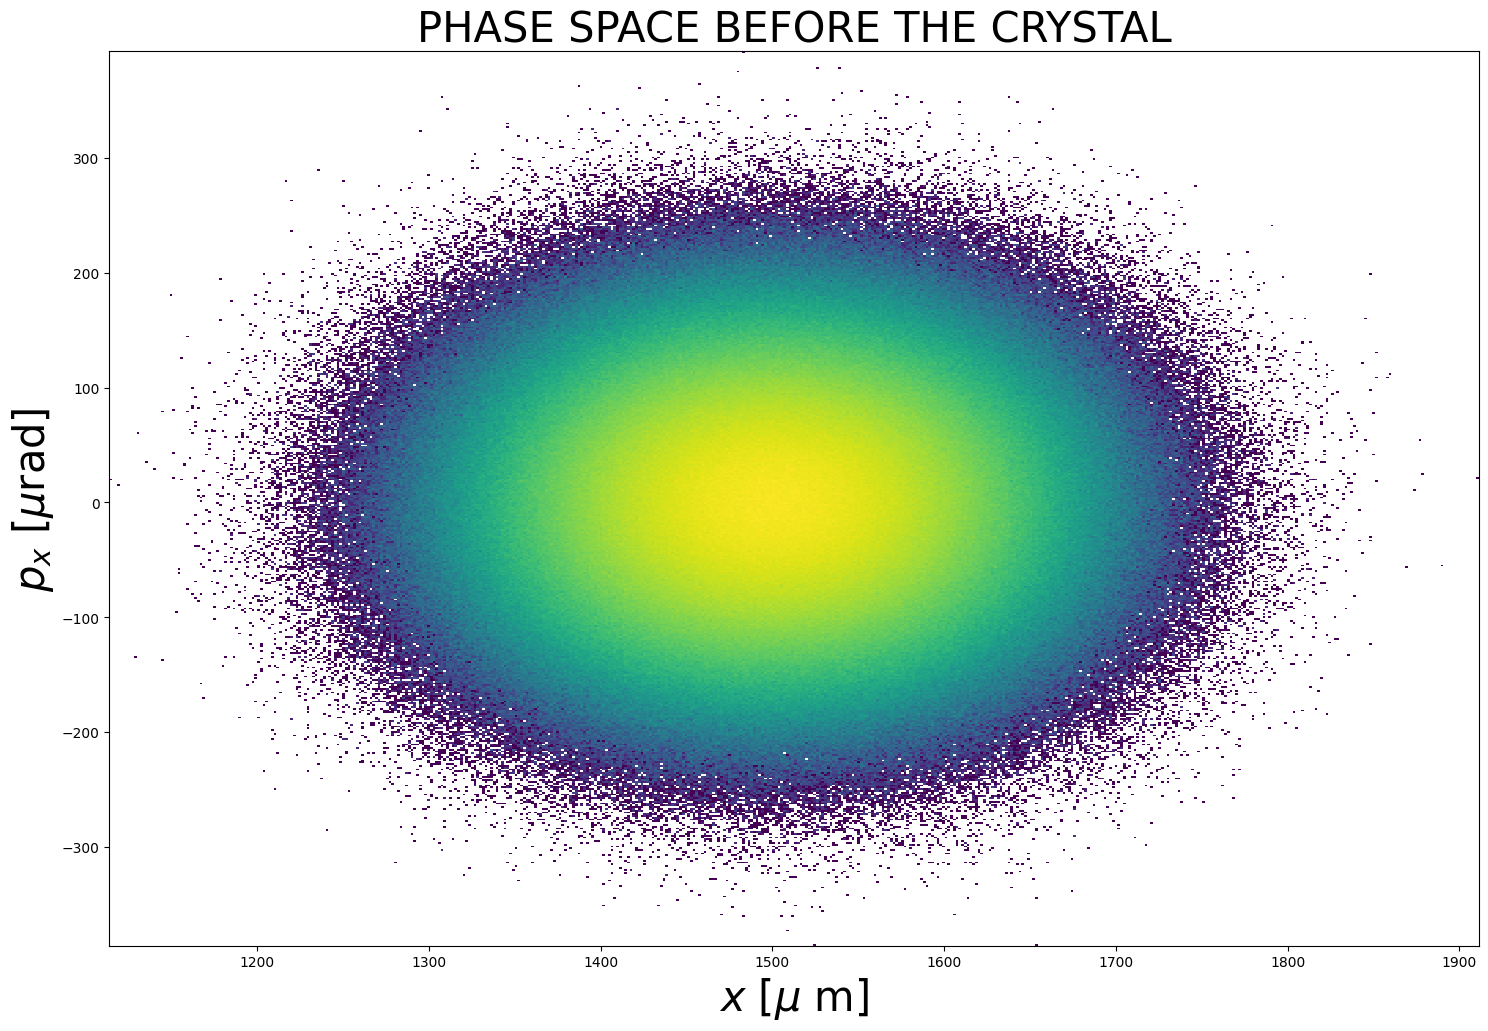

In [5]:
plt.figure(figsize=(15,10))
plt.hist2d(part_init.x*1.e6, part_init.px*1.e6, 500, norm=mpl.colors.LogNorm())
#plt.xlim(-30, 180)
#plt.ylim(-100, 300)
plt.xlabel(r'$x$ [$\mu$ m]',fontsize=30)
plt.ylabel(r'$p_x$ [$\mu$rad]',fontsize=30)
plt.tight_layout()
plt.title('PHASE SPACE BEFORE THE CRYSTAL', fontsize=30)
plt.show()

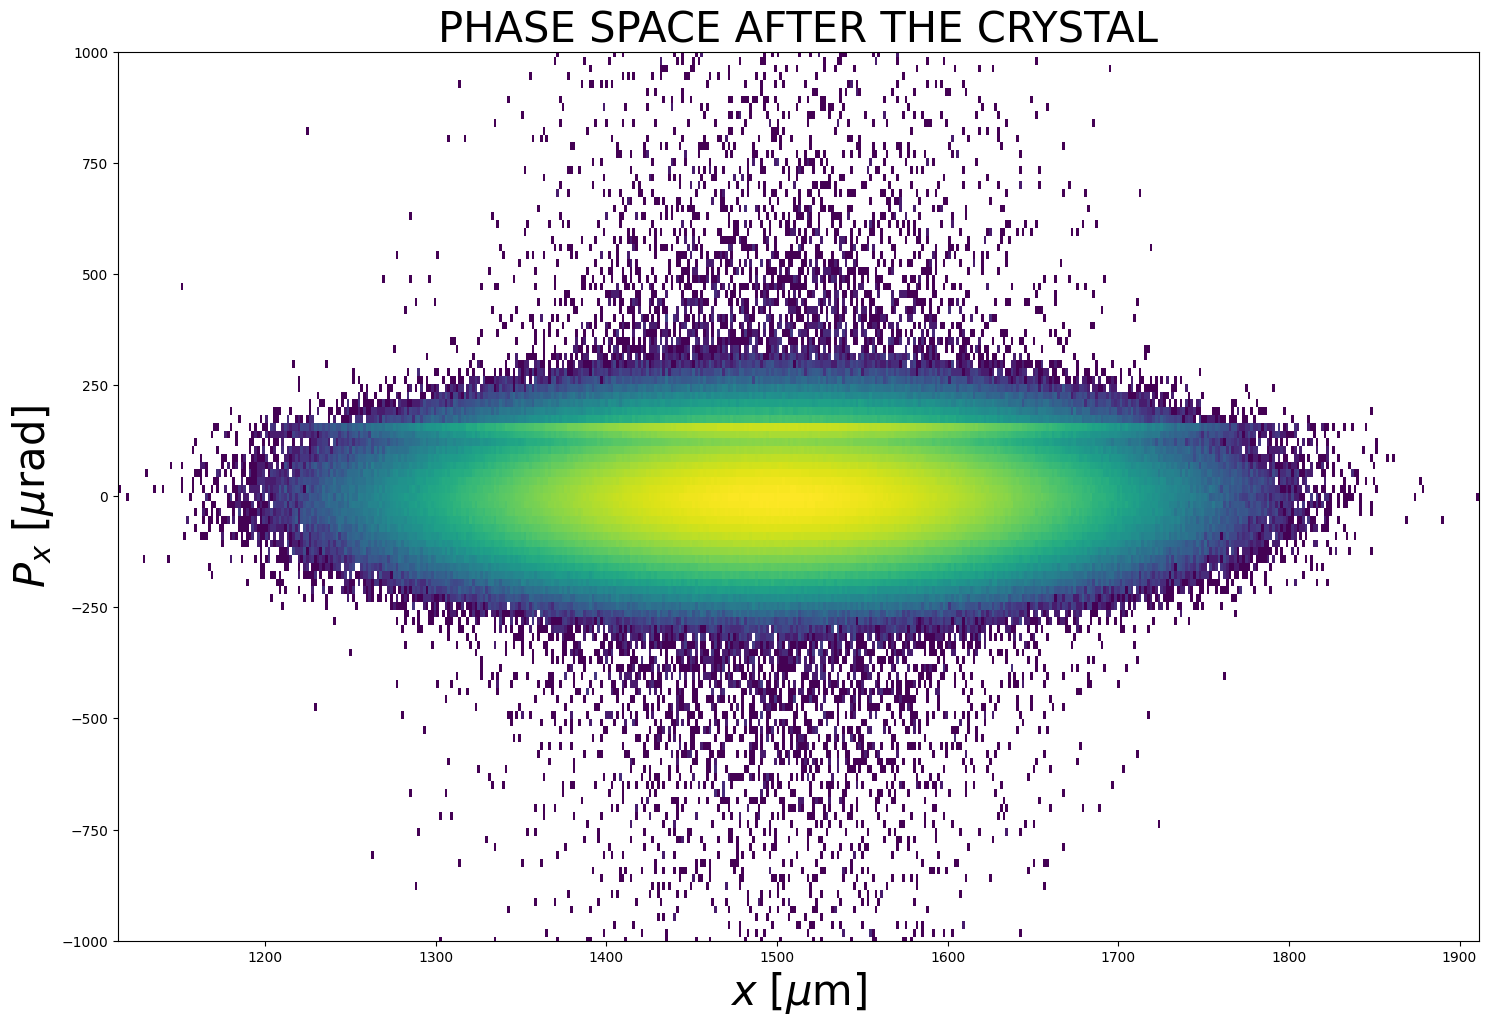

In [6]:
plt.figure(figsize=(15,10))
plt.hist2d(part.x*1.e6, part.px*1.e6, 500, norm=mpl.colors.LogNorm())
#plt.xlim(-30, 180)
plt.ylim(-1000, 1000)
plt.xlabel(r'$x$ [$\mu$m]',fontsize=30)
plt.ylabel(r'$P_x$ [$\mu$rad]',fontsize=30)
plt.tight_layout()
plt.title('PHASE SPACE AFTER THE CRYSTAL',fontsize=30)
plt.show()

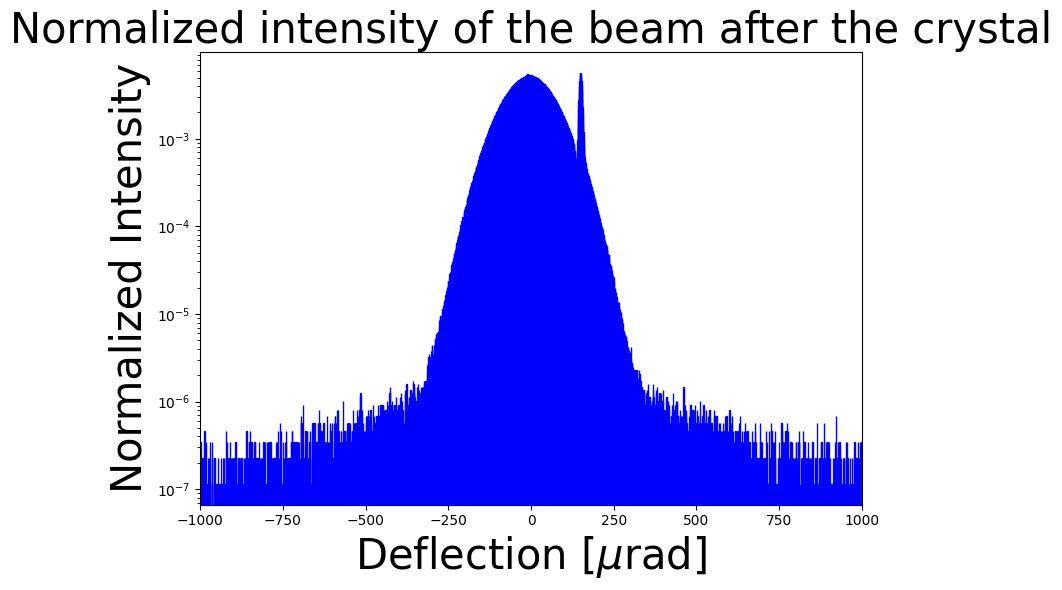

In [7]:
plt.figure(figsize=(8,6))
plt.hist(part.px * 1.e6, bins=10000, density=True, log=True, color='blue', edgecolor='blue')
plt.xlabel(r'Deflection [$\mu$rad]', fontsize=30)
plt.xlim(-1000, 1000)
plt.ylabel('Normalized Intensity', fontsize= 30)
plt.title(r'Normalized intensity of the beam after the crystal',fontsize=30)
plt.tight_layout()
plt.show()

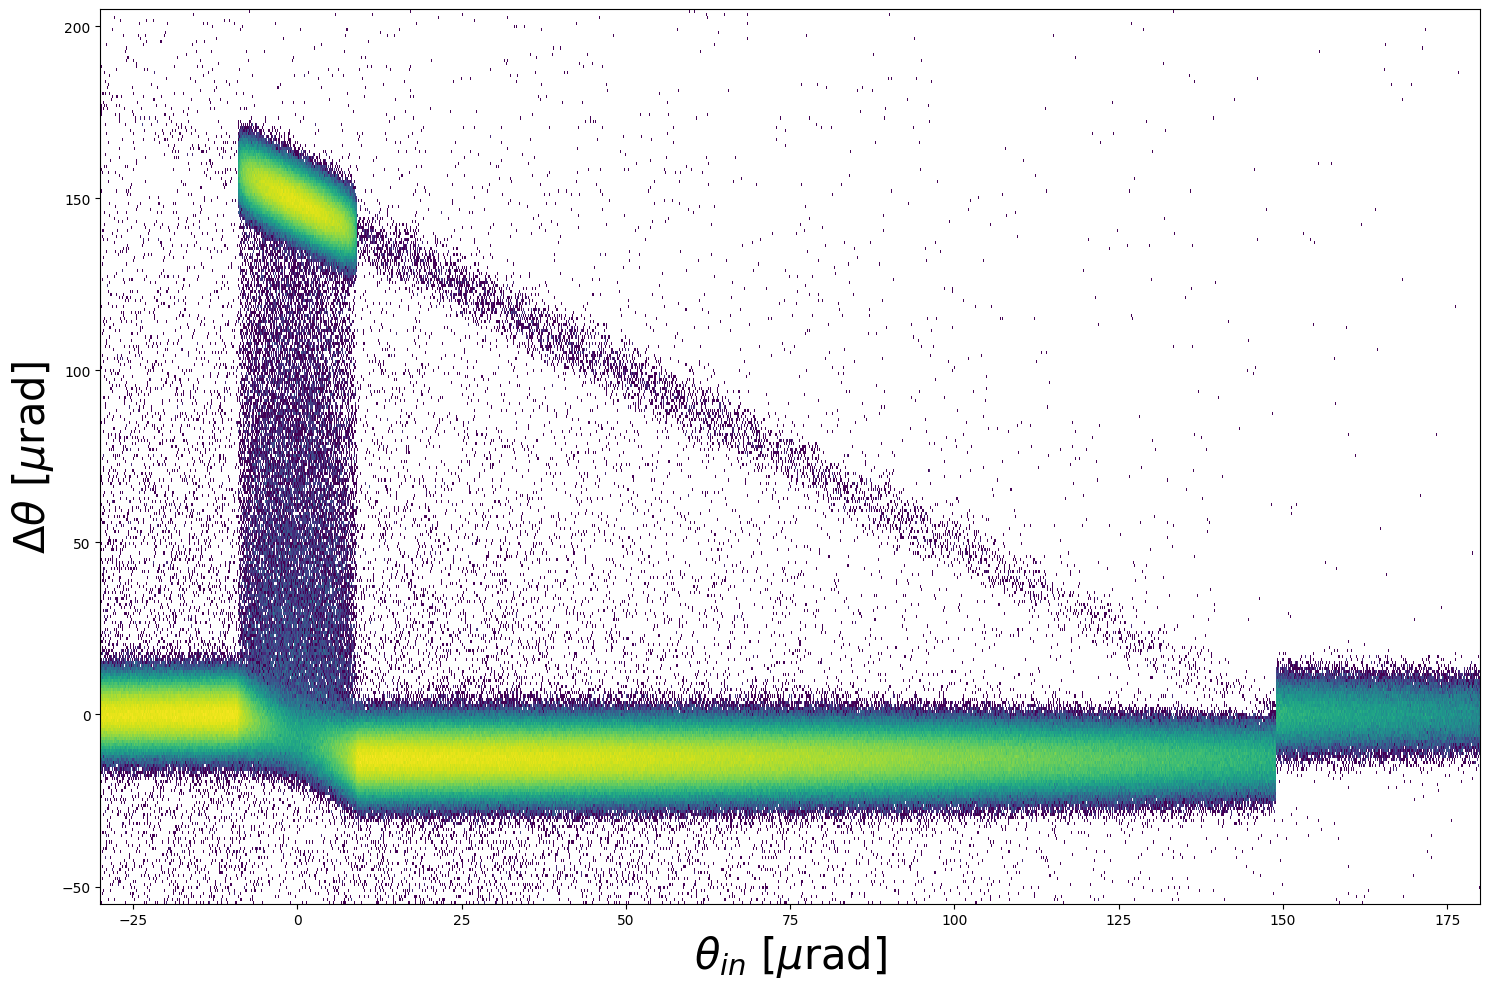

In [8]:
plt.figure(figsize=(15,10))
plt.hist2d(part_init.px*1.e6, part.px*1.e6 - part_init.px*1.e6, 10000, norm=mpl.colors.LogNorm())
plt.xlim(-30, 180)
plt.ylim(-55, 205)
#plt.title(r' ')
plt.ylabel(r'$\Delta\theta$ [$\mu$rad]', fontsize=30)
plt.xlabel(r'$\theta_{in}$ [$\mu$rad]', fontsize=30)
plt.tight_layout()
plt.show()